<a href="https://colab.research.google.com/github/sw030701-ai/motor-control-optimization/blob/main/experiments/04_rl_direct_voltage_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. RL Direct Voltage Control

이 notebook은 PID gain tuning이 아니라 `RL Direct Voltage Control` 실험을 정리한다.
RL agent는 현재 state `[e_t, omega_t, i_t]`를 보고 매 time step마다 voltage `V_t`를 직접 출력한다.

```text
[e_t, omega_t, i_t] -> TD3 agent -> V_t -> DC motor
```

`V_t`는 실제 actuator limit을 반영해서 `-12 V`부터 `12 V` 사이로 clip한다.

## 실험 방향

기존 PID optimization은 좋은 `K_p`, `K_i`, `K_d`를 찾는 문제이다.
반면 이 실험의 RL controller는 PID 구조를 쓰지 않고, state를 보고 voltage를 직접 결정한다.

| Controller | 제어 방식 |
|---|---|
| Manual PID | 사람이 고정 PID gains를 선택 |
| Optimized PID | optimizer가 고정 PID gains를 탐색 |
| RL Direct Control | TD3 policy가 voltage를 직접 출력 |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULT_TABLE_DIR = PROJECT_ROOT / "results" / "tables"
RESULT_FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
RESULT_MODEL_DIR = PROJECT_ROOT / "results" / "models"

comparison_path = RESULT_TABLE_DIR / "direct_voltage_rl_comparison.csv"
training_history_path = RESULT_TABLE_DIR / "rl_direct_voltage_training_history.csv"
eval_history_path = RESULT_TABLE_DIR / "rl_direct_voltage_eval_history.csv"
evaluation_path = RESULT_TABLE_DIR / "rl_direct_voltage_evaluation.csv"
summary_path = RESULT_TABLE_DIR / "rl_direct_voltage_summary.json"
best_actor_path = RESULT_MODEL_DIR / "td3_direct_voltage_best_actor.pt"
last_actor_path = RESULT_MODEL_DIR / "td3_direct_voltage_last_actor.pt"
speed_plot_path = RESULT_FIGURE_DIR / "rl_direct_voltage_speed_comparison.png"
voltage_plot_path = RESULT_FIGURE_DIR / "rl_direct_voltage_control_comparison.png"


/Users/seong-uuimac/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/js/s5xbjpb56mn1ysk430xc81w40000gn/T/matplotlib-ausizirr because there was an issue with the default path (/Users/seong-uuimac/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories
Fontconfig error: No writable cache directories


Matplotlib is building the font cache; this may take a moment.


## 고정 조건

비교 조건은 기존 main 실험과 동일하게 둔다.

| 항목 | 값 |
|---|---|
| Motor model | `nominal_dc_motor_params()` |
| Reference speed | `12.6 rad/s` |
| Voltage limit | `-12 V <= V_t <= 12 V` |
| Initial state | `omega(0)=0`, `i(0)=0` |
| Simulation time | Training/evaluation 모두 10초 조건 사용 |
| Evaluation metric | 기존 `compute_cost()`와 `is_feasible_v1()` |
| Best checkpoint metric | deterministic evaluation의 최소 `J_total` |


## TD3 선택 이유

이 실험에서는 `TD3`를 사용한다.
Action이 motor voltage이므로 continuous action이고, action dimension은 1개이다.
따라서 deterministic policy가 voltage를 직접 출력하는 TD3가 현재 v1 실험에 자연스럽다.

`SAC`도 사용할 수 있지만, 이 프로젝트 단계에서는 TD3가 구현 의존성과 tuning 부담이 더 작다.

## Reward 설계

reward는 기존 PID optimization의 cost 철학을 따른다. 즉 tracking error, overshoot, control effort를 모두 반영한다.

```math
r_t = -\left[
0.60\left(\frac{e_t}{\omega_{ref}}\right)^2
+0.25\left(\max\left(0,\frac{\omega_t-\omega_{ref}}{\omega_{ref}}\right)\right)^2
+0.15\left(\frac{V_t}{V_{max}}\right)^2
\right]
```

학습 reward와 최종 evaluation metric이 완전히 같은 것은 아니지만, 둘 다 tracking, overshoot, voltage effort를 보는 같은 방향의 기준이다.

## 학습 과정

Training episode에서는 exploration noise와 actor/critic update를 켠다.
Evaluation에서는 exploration을 끄고 deterministic action만 사용하며, network update를 하지 않는다.

기본 script 설정은 매 10 episode마다 deterministic evaluation을 수행한다.
Best checkpoint는 기존 프로젝트 cost인 `compute_cost()`의 `J_total`이 가장 낮은 evaluation policy로 선택한다.
최종 비교에서도 마지막 episode actor가 아니라 이 best checkpoint를 다시 로드해서 사용한다.

학습 안정화를 위해 actor learning rate와 critic learning rate는 기존 `3e-4`에서 각각 `1e-4`로 낮췄다.


In [2]:
training_history = pd.read_csv(training_history_path)
display(training_history)

,episode,episode_reward,final_omega,final_error,critic_loss,actor_loss,eval_J_total,best_eval_episode,best_eval_J_total
0,1,-1287.604209,0.685346,11.914654,0.000672,2.814254,NaN,NaN,NaN
1,2,-1243.809710,4.581627,8.018373,0.000644,NaN,NaN,NaN,NaN
2,3,-427.318318,5.995422,6.604578,0.000918,6.406102,NaN,NaN,NaN
3,4,-412.394429,5.280643,7.319357,0.002115,NaN,NaN,NaN,NaN
4,5,-1043.409300,23.454380,-10.854380,0.439356,6.587746,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
95,96,-99.363788,11.921085,0.678915,0.000533,NaN,NaN,20.0,0.034903
96,97,-94.974421,11.214478,1.385522,0.000603,5.103358,NaN,20.0,0.034903
97,98,-94.630993,11.441850,1.158150,0.002821,NaN,NaN,20.0,0.034903
98,99,-127.331602,10.346445,2.253555,0.000605,4.596447,NaN,20.0,0.034903


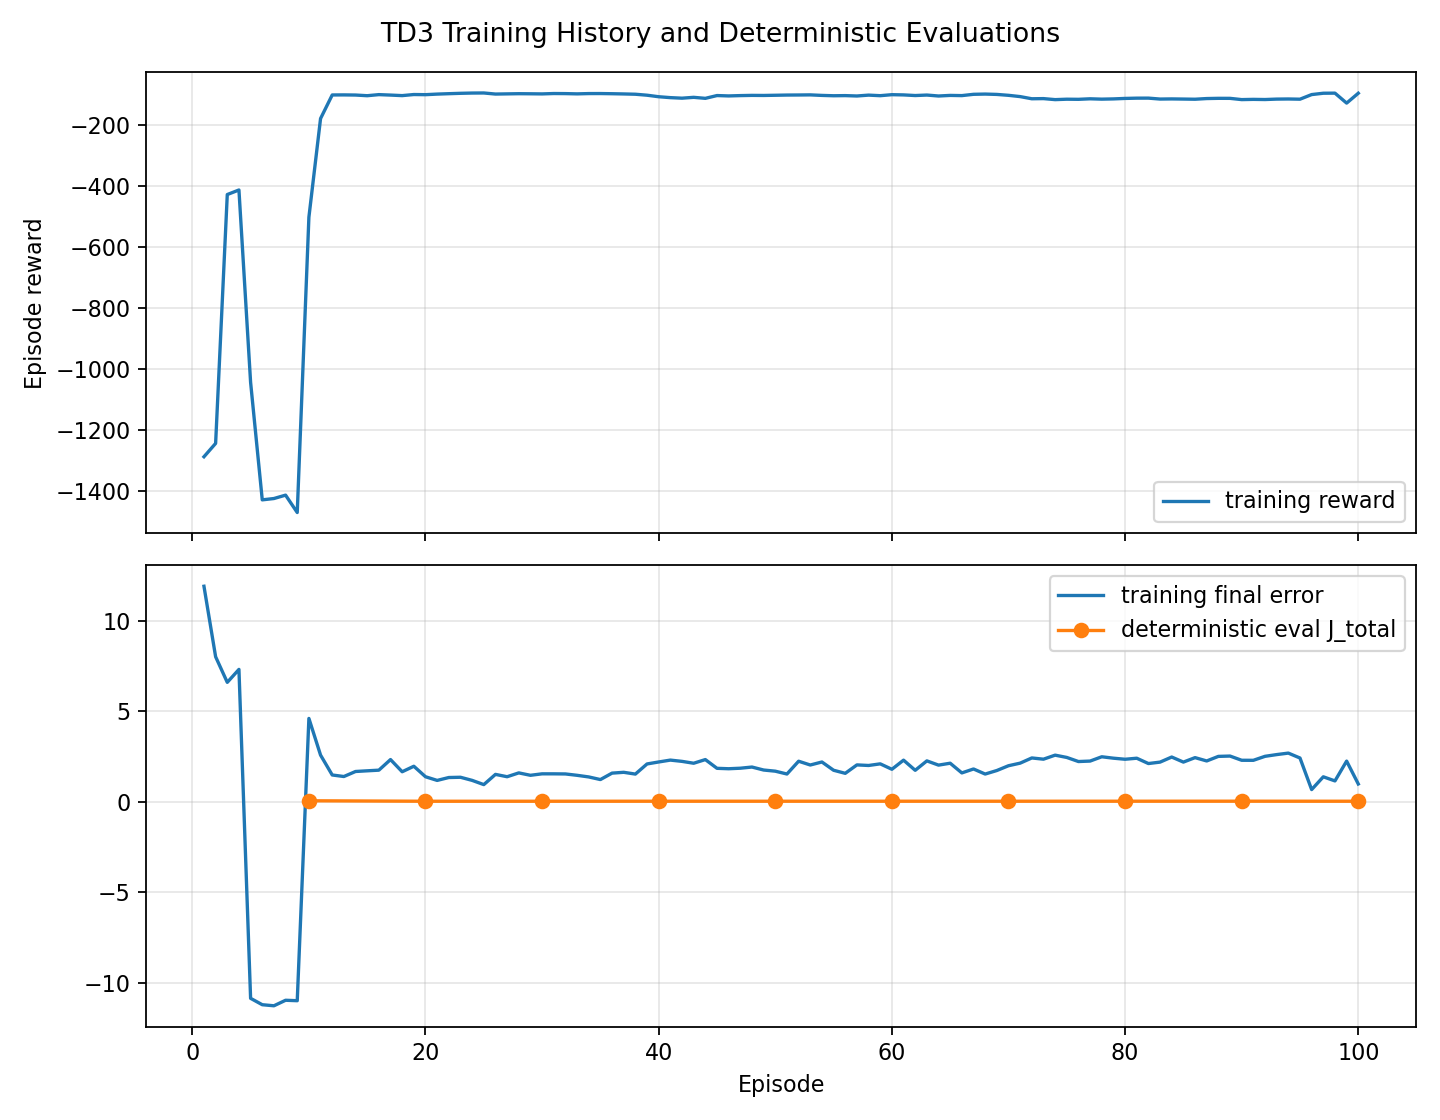

In [3]:
display(Image(filename=str(RESULT_FIGURE_DIR / "rl_direct_voltage_training_history.png")))

In [4]:
if eval_history_path.exists():
    eval_history = pd.read_csv(eval_history_path)
    display(eval_history)
else:
    print("Run experiments/04_rl_direct_voltage_control.py to create evaluation checkpoint history.")


,J_total,J_tracking,J_overshoot,J_control,overshoot_percent,settling_time,steady_state_error_percent,voltage_max_abs,saturation_percent,omega_final,feasible,episode,checkpoint_metric,checkpoint_score,is_best_checkpoint
0,0.060976,0.076892,0.0,0.098942,0.0,inf,39.206949,11.999601,0.189981,7.659924,False,10,J_total,0.060976,False
1,0.034903,0.007779,0.0,0.201571,0.0,inf,12.430304,12.000000,0.599940,11.033782,False,20,J_total,0.034903,True
2,0.034953,0.006542,0.0,0.206848,0.0,inf,11.396785,12.000000,0.749925,11.164005,False,30,J_total,0.034953,False
3,0.036180,0.015053,0.0,0.180984,0.0,inf,17.325984,12.000000,0.709929,10.416926,False,40,J_total,0.036180,False
4,0.035684,0.012462,0.0,0.188042,0.0,inf,15.762583,12.000000,0.709929,10.613915,False,50,J_total,0.035684,False
5,0.036300,0.015020,0.0,0.181922,0.0,inf,17.313097,12.000000,0.729927,10.418550,False,60,J_total,0.036300,False
6,0.035709,0.012160,0.0,0.189420,0.0,inf,15.569838,12.000000,0.819918,10.638200,False,70,J_total,0.035709,False
7,0.036768,0.017060,0.0,0.176878,0.0,inf,18.450928,12.000000,0.639936,10.275183,False,80,J_total,0.036768,False
8,0.037765,0.020647,0.0,0.169180,0.0,inf,20.307673,12.000000,0.519948,10.041233,False,90,J_total,0.037765,False
9,0.035425,0.003065,0.0,0.223903,0.0,inf,7.770393,12.000000,0.639936,11.620931,False,100,J_total,0.035425,False


## 최종 비교 결과

Manual PID, Optimized PID, RL Direct Control을 같은 `compute_cost()` metric으로 비교한다.
RL Direct Control row는 마지막 training episode가 아니라 `td3_direct_voltage_best_actor.pt`에서 다시 로드한 best deterministic evaluation checkpoint의 결과이다.


In [5]:
comparison = pd.read_csv(comparison_path)
show_columns = [
    "Controller",
    "J_total",
    "J_tracking",
    "J_overshoot",
    "J_control",
    "overshoot_percent",
    "settling_time",
    "steady_state_error_percent",
    "voltage_max_abs",
    "saturation_percent",
    "omega_final",
    "feasible",
    "J_improvement_vs_manual_percent",
]
display(comparison[show_columns])

,Controller,J_total,J_tracking,J_overshoot,J_control,overshoot_percent,settling_time,steady_state_error_percent,voltage_max_abs,saturation_percent,omega_final,feasible,J_improvement_vs_manual_percent
0,Manual PID,0.038177,0.000114,0.000000e+00,0.254054,0.00000,1.322,2.158821e-07,10.242803,0.00000,12.600000,True,0.000000
1,Optimized PID,0.036702,0.000611,7.499755e-09,0.242238,0.00866,1.547,4.709601e-10,6.001635,0.00000,12.600000,True,3.861902
2,RL Direct Control,0.034903,0.007779,0.000000e+00,0.201571,0.00000,inf,1.243030e+01,12.000000,0.59994,11.033782,False,8.573806


## RL 평가 결과만 확인

아래 표는 최종 비교에 사용한 RL best checkpoint의 evaluation 결과만 따로 정리한 것이다.


In [6]:
rl_evaluation = pd.read_csv(evaluation_path)
display(rl_evaluation.T.rename(columns={0: "value"}))

,value
Controller,RL Direct Control
K_p,NaN
K_i,NaN
K_d,NaN
J_total,0.034903
J_tracking,0.007779
J_overshoot,0.0
J_control,0.201571
overshoot_percent,0.0
settling_time,inf


## 시뮬레이션 응답

아래 plot은 같은 motor, 같은 reference, 같은 voltage limit에서 세 controller의 speed response와 voltage response를 비교한 것이다.

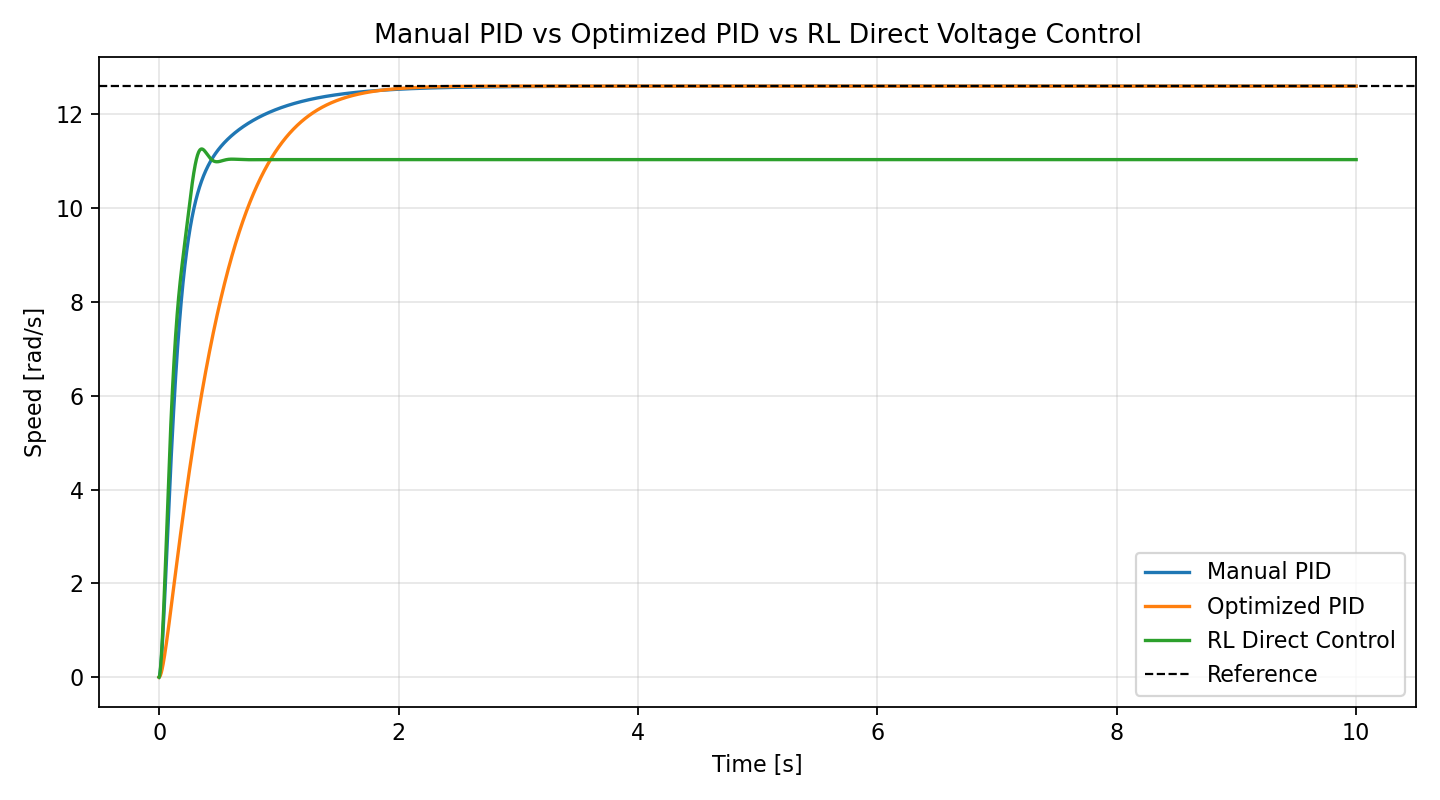

In [7]:
display(Image(filename=str(speed_plot_path)))

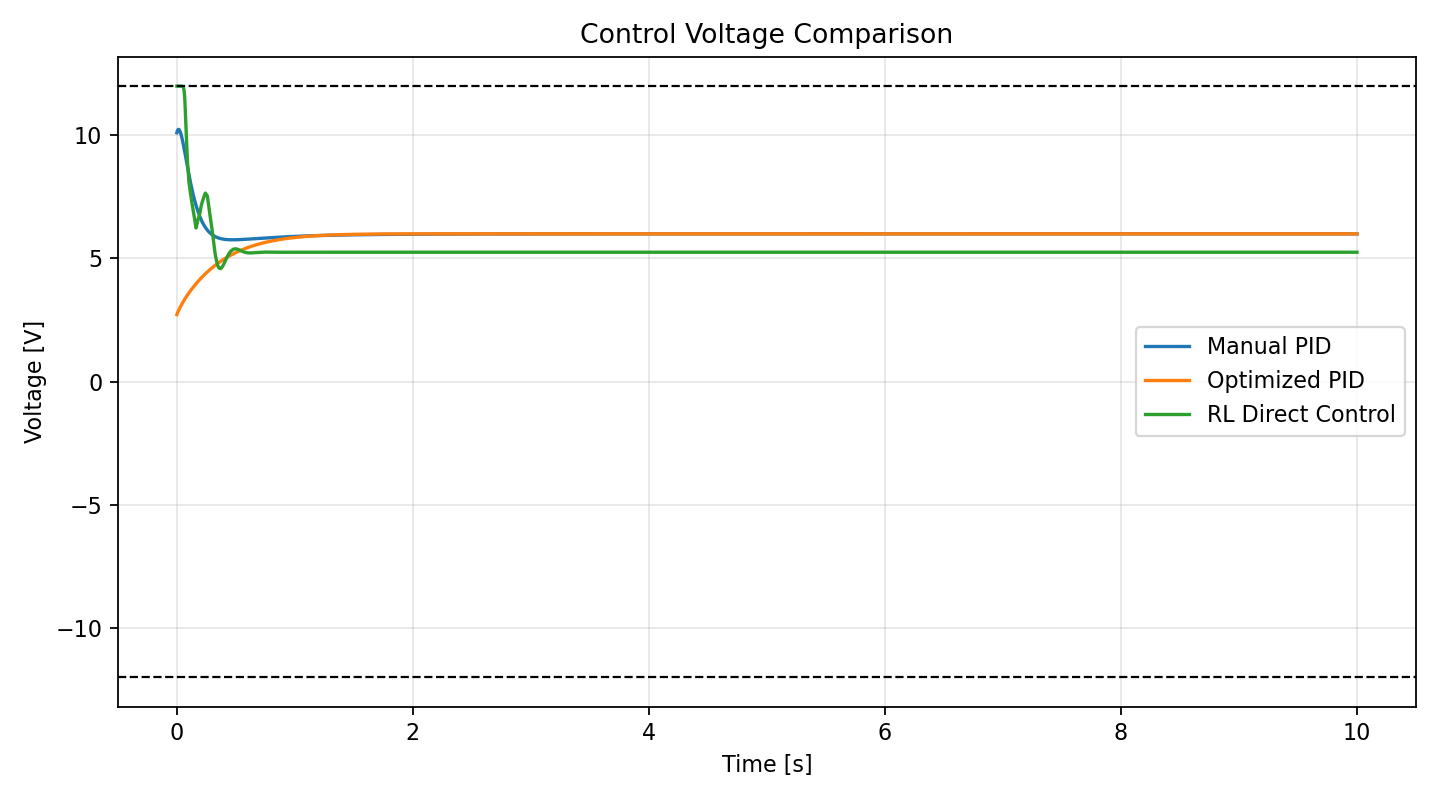

In [8]:
display(Image(filename=str(voltage_plot_path)))

## 결과 해석

RL Direct Control은 training 중 exploration 때문에 episode reward와 final speed가 흔들릴 수 있다.
그래서 이 실험에서는 training 기록만으로 정책을 선택하지 않고, 매 10 episode마다 deterministic evaluation을 분리해서 수행한다.

Checkpoint 선택 기준은 기존 PID 비교와 같은 `compute_cost()`의 `J_total` 최소화이다.
이렇게 하면 후반 training episode가 일시적으로 나빠져도, 지금까지 검증된 best policy를 최종 comparison에 사용할 수 있다.

현재의 단순 state, reward, training budget에서는 Optimized PID가 더 안정적일 수 있다.
따라서 RL 결과는 direct RL control을 적용할 때 reward shaping, 학습 안정화, 검증 절차가 중요하다는 한계 분석으로 해석한다.
